In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your master dataset
df = pd.read_csv('../data/west_africa_solar_data_2014_2025.csv')

# Convert Year and Month to a proper datetime index
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

print(df.shape)
print(df.dtypes)
print(df.head())

(2574, 9)
City                       str
Country                    str
Climate_Zone               str
Year                     int64
Month                    int64
GHI                    float64
DNI                    float64
DHI                    float64
Date            datetime64[us]
dtype: object
    City  Country   Climate_Zone  Year  Month     GHI     DNI     DHI  \
0  Lagos  Nigeria  Coastal Humid  2014      1  4.7650  2.6323  2.5373   
1  Lagos  Nigeria  Coastal Humid  2014      2  4.5350  1.6327  2.7288   
2  Lagos  Nigeria  Coastal Humid  2014      3  4.9625  2.0602  2.7432   
3  Lagos  Nigeria  Coastal Humid  2014      4  5.0311  2.2757  2.7475   
4  Lagos  Nigeria  Coastal Humid  2014      5  4.7712  2.1888  2.5555   

        Date  
0 2014-01-01  
1 2014-02-01  
2 2014-03-01  
3 2014-04-01  
4 2014-05-01  


In [2]:
# ================================================
# RESAMPLE — aggregate data by time period
# ================================================

# Set Date as index for one city first
lagos = df[df['City'] == 'Lagos'].copy()
lagos = lagos.set_index('Date')

# Resample to annual average GHI
lagos_annual = lagos['GHI'].resample('YE').mean().round(3)

print("=== Lagos Annual Average GHI ===")
print(lagos_annual)
print(f"\nOverall mean: {lagos_annual.mean():.3f} kWh/m²/day")
print(f"Best year:    {lagos_annual.idxmax().year} ({lagos_annual.max():.3f})")
print(f"Worst year:   {lagos_annual.idxmin().year} ({lagos_annual.min():.3f})")

=== Lagos Annual Average GHI ===
Date
2014-12-31    4.482
2015-12-31    4.583
2016-12-31    4.637
2017-12-31    4.505
2018-12-31    4.582
2019-12-31    4.514
2020-12-31    4.697
2021-12-31    4.623
2022-12-31    4.609
2023-12-31    4.654
2024-12-31    4.685
2025-12-31    4.523
Freq: YE-DEC, Name: GHI, dtype: float64

Overall mean: 4.591 kWh/m²/day
Best year:    2020 (4.697)
Worst year:   2014 (4.482)


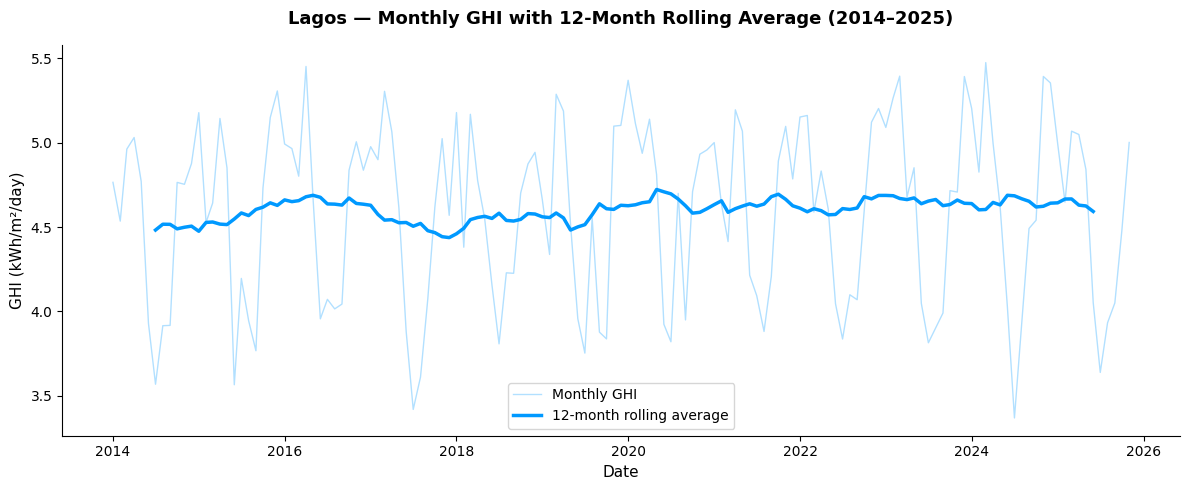

Chart saved!


In [3]:
# ================================================
# ROLLING AVERAGE — smooth out noise to see trend
# ================================================

# Set index for all cities
df_indexed = df.copy()
df_indexed = df_indexed.set_index('Date')

# Rolling 12-month average for Lagos
lagos_rolling = lagos['GHI'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Raw monthly values
ax.plot(lagos.index, lagos['GHI'],
        color='#0099ff', alpha=0.3, linewidth=1,
        label='Monthly GHI')

# 12-month rolling average
ax.plot(lagos.index, lagos_rolling,
        color='#0099ff', linewidth=2.5,
        label='12-month rolling average')

ax.set_title('Lagos — Monthly GHI with 12-Month Rolling Average (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('GHI (kWh/m²/day)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/lagos_rolling_avg.png', dpi=150)
plt.show()
print("Chart saved!")

## What the rolling average reveals:

Lagos GHI is remarkably stable. The rolling average stays between 4.4 and 4.7 kWh/m²/day for the entire 11 years. No upward or downward drift in the rolling average confirms the Mann-Kendall test finding of no significant trend. The dips below 3.5 are likely peak rainy season months, July/August cloud cover at its worst

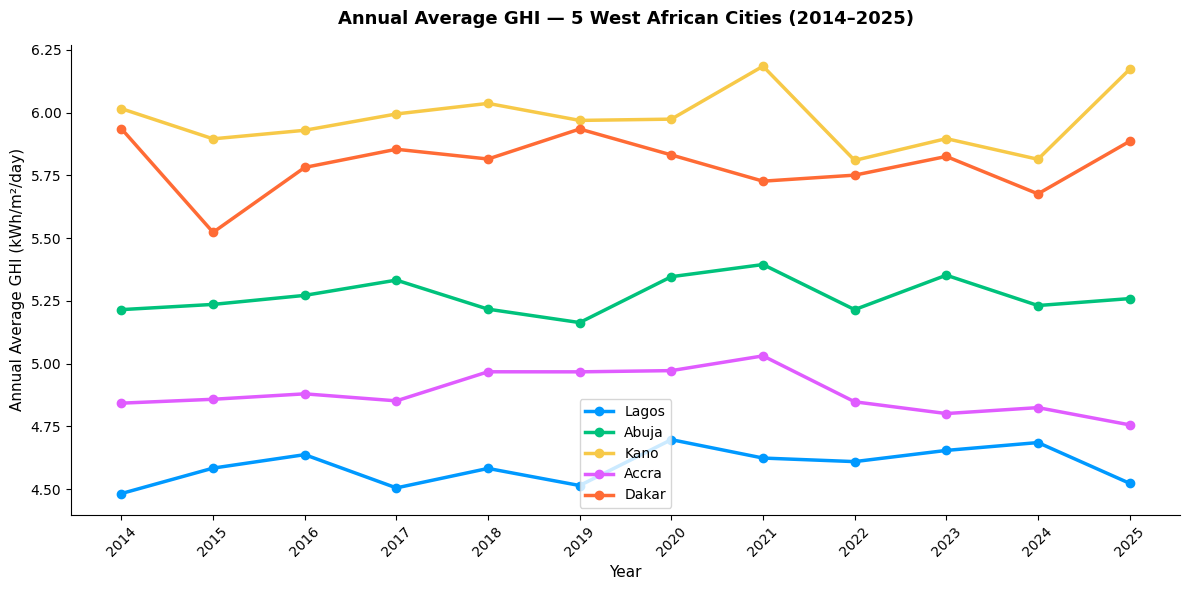

Chart saved!


In [4]:
# ================================================
# RESAMPLE — 5 city annual comparison
# ================================================

cities_5 = ['Lagos', 'Abuja', 'Kano', 'Accra', 'Dakar']

colors_5 = {
    'Lagos': '#0099ff',
    'Abuja': '#00c27c',
    'Kano':  '#f7c948',
    'Accra': '#e05cff',
    'Dakar': '#ff6b35'
}

fig, ax = plt.subplots(figsize=(12, 6))

for city in cities_5:
    city_df = df[df['City'] == city].copy()
    city_df = city_df.set_index('Date')
    
    # Resample to annual average
    annual = city_df['GHI'].resample('YE').mean()
    
    ax.plot(annual.index.year, annual.values,
            marker='o', linewidth=2.5, markersize=6,
            label=city, color=colors_5[city])

ax.set_title('Annual Average GHI — 5 West African Cities (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Annual Average GHI (kWh/m²/day)', fontsize=11)
ax.set_xticks(range(2014, 2026))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/5city_annual_ghi.png', dpi=150)
plt.show()
print("Chart saved!")

## What stands out:

Kano consistently leads. The yellow line stays above all others throughout 11 years. Northern Nigeria's solar advantage is persistent, not occasional
Dakar and Kano converge in 2021, both spike upward that year. Likely a regional climate anomaly worth noting
Lagos stays flat at the bottom, the most commercially important city in Nigeria has the worst solar resource. 
2022 dip across all cities

=== GHI Correlation Matrix — 5 Cities ===
City   Abuja  Accra  Dakar   Kano  Lagos
City                                    
Abuja  1.000  0.798  0.105  0.467  0.839
Accra  0.798  1.000  0.159  0.390  0.858
Dakar  0.105  0.159  1.000  0.659  0.020
Kano   0.467  0.390  0.659  1.000  0.214
Lagos  0.839  0.858  0.020  0.214  1.000


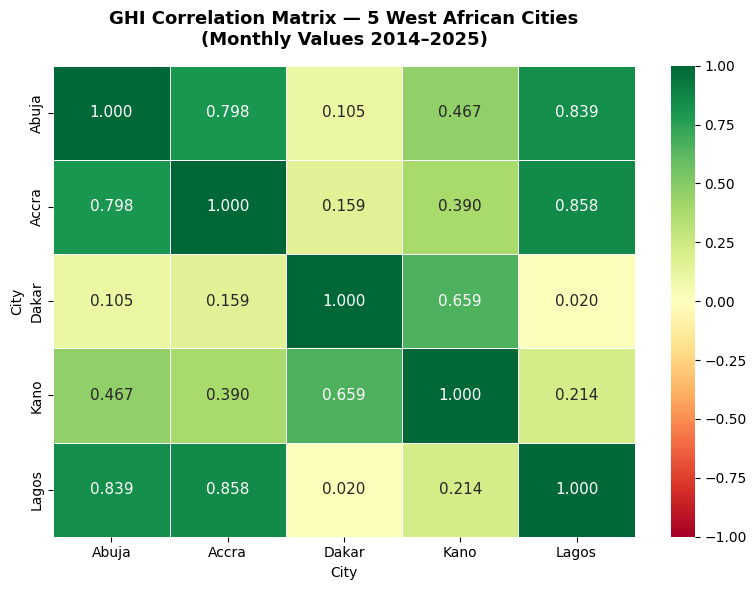

Chart saved!


In [5]:
# ================================================
# CORRELATION ANALYSIS
# How similar are cities' solar patterns?
# ================================================

# Pivot — cities as columns, date as rows
pivot_df = df[df['City'].isin(cities_5)].pivot_table(
    index='Date', columns='City', values='GHI'
)

# Correlation matrix
corr_matrix = pivot_df.corr().round(3)

print("=== GHI Correlation Matrix — 5 Cities ===")
print(corr_matrix.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('GHI Correlation Matrix — 5 West African Cities\n(Monthly Values 2014–2025)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/ghi_correlation_matrix.png', dpi=150)
plt.show()
print("Chart saved!")

# High correlations:

Lagos & Accra: 0.858  (two coastal humid cities 500km apart sharing almost identical seasonal patterns).
Lagos & Abuja: 0.839 (surprising given their different climate zones). 

Nigeria's coastal-savanna connection is stronger than expected.
Abuja & Accra: 0.798 (savanna and coastal humid sharing strong seasonal similarity).

## Low correlations:

Dakar & Lagos: 0.020 (zero correlation). These two cities have completely independent solar patterns despite both being West African coastal cities. Dakar faces the Atlantic at 14°N with Sahel influence. Lagos faces the Gulf of Guinea at 6°N with equatorial influence. Completely different climate drivers.
Dakar & Abuja: 0.105 (also near zero).

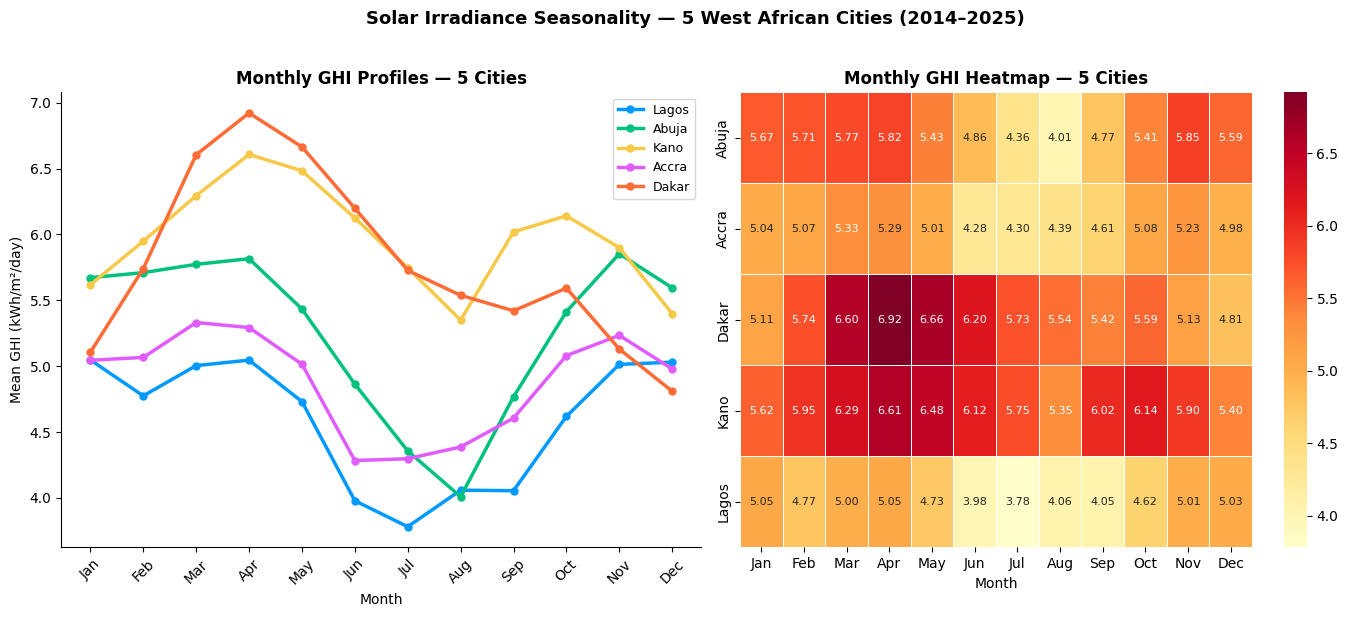

Chart saved!


In [6]:
# ================================================
# SEASONALITY — monthly patterns by city
# ================================================

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Calculate monthly averages for each city
monthly_city = df[df['City'].isin(cities_5)].groupby(
    ['City', 'Month'])['GHI'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT — line chart showing all 5 cities
ax1 = axes[0]
for city in cities_5:
    city_data = monthly_city[monthly_city['City'] == city]
    ax1.plot(month_names, city_data['GHI'].values,
             marker='o', linewidth=2.5, markersize=5,
             label=city, color=colors_5[city])

ax1.set_title('Monthly GHI Profiles — 5 Cities',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Mean GHI (kWh/m²/day)', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='x', rotation=45)

# RIGHT — heatmap showing seasonality
pivot_monthly = monthly_city.pivot(
    index='City', columns='Month', values='GHI'
).round(2)
pivot_monthly.columns = month_names

ax2 = axes[1]
sns.heatmap(
    pivot_monthly,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax2,
    annot_kws={'size': 8}
)
ax2.set_title('Monthly GHI Heatmap — 5 Cities',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=10)
ax2.set_ylabel('')

plt.suptitle('Solar Irradiance Seasonality — 5 West African Cities (2014–2025)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/seasonality_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Time Series Analysis: Key Interpretations

### Rolling Average and Long-Term Stability
The 12-month rolling average for Lagos reveals a highly stable solar resource over 11 years, with the smoothed trend remaining between 4.4 and 4.7 kWh/m²/day throughout 2014–2025. The regular oscillations in monthly raw values reflect the seasonal cycle repeating predictably every 12 months. The absence of any upward or downward drift confirms the Mann-Kendall finding of no statistically significant long-term trend. This is a reassuring signal 
for long-term solar investment planning in coastal West Africa.

### Annual Comparison and the 2022 Anomaly
The 5-city annual comparison reveals a persistent solar resource hierarchy. Kano consistently leads while Lagos consistently trails. That's not a 
coincidence. When every city in a region moves in the same direction at the same time, something bigger than local weather is at work. 

### Seasonality and Correlation
The correlation matrix was the most surprising result. Lagos and Accra, two coastal cities sharing the same Gulf of Guinea climate system move almost in lockstep (0.858). But Dakar and Lagos has nearly zero correlation (0.020). Despite both being West African coastal cities, they behave like they're on different planets. Dakar sits on a peninsula jutting into the Atlantic at 
14°N, shaped by cold ocean currents and Saharan air. Lagos sits in the Gulf of Guinea at 6°N, shaped by tropical monsoons. 
Same continent, completely different solar stories. This matters enormously for anyone thinking about regional solar grids. One cannot assume cities will peak and dip together just because they're geographically close.